#Text-to-Image-to-Video_Hugging_Face


Initializing Robust API Client...
Target Prompt: 'a cute 3d robot exploring a glowing neon forest, cinematic lighting, high resolution'
----------------------------------------
Attempting generation with: black-forest-labs/FLUX.1-schnell...
✅ Success! Image generated.


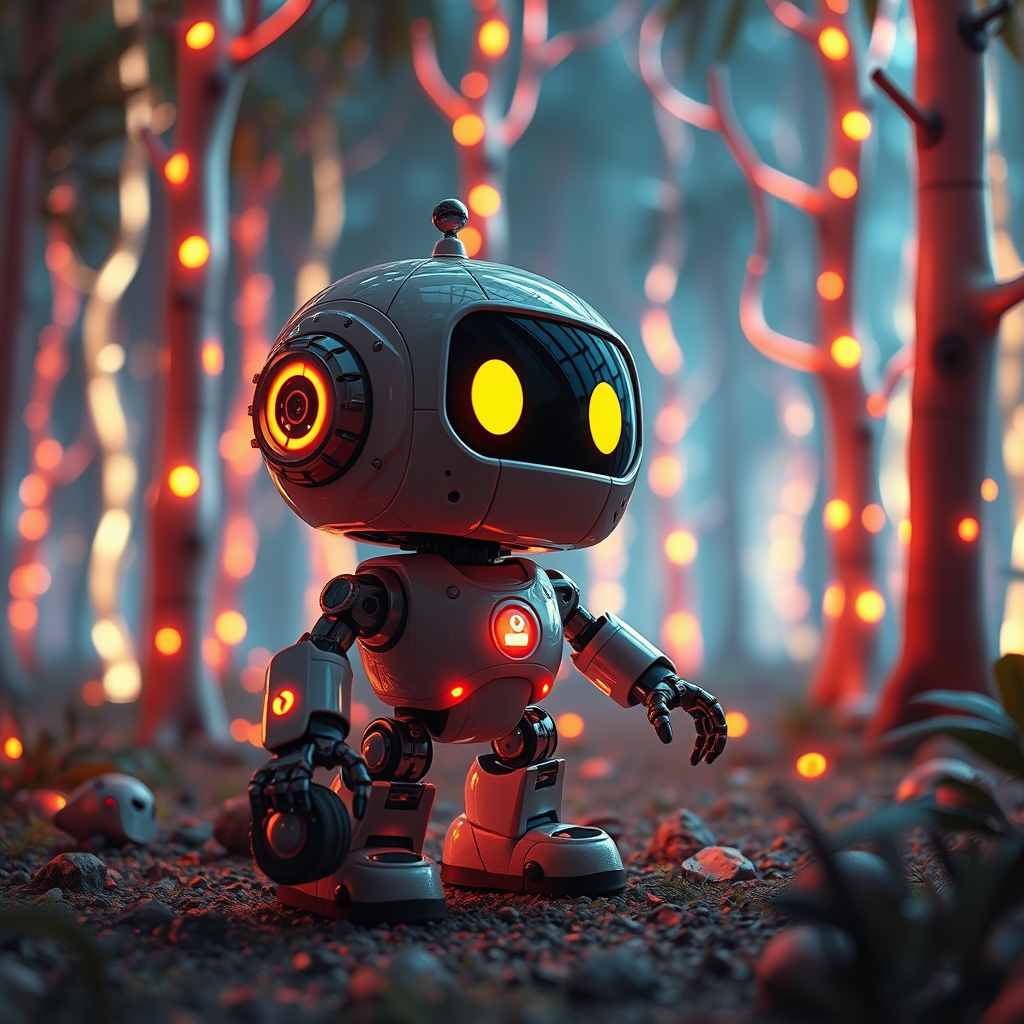

In [2]:
!pip install -q huggingface_hub

import os
from huggingface_hub import InferenceClient
from PIL import Image
from google.colab import userdata
from IPython.display import display

print("Initializing Robust API Client...")

# 1. Load your token and initialize the official client
hf_token = userdata.get('HF_TOKEN')
client = InferenceClient(token=hf_token)

prompt = "a cute 3d robot exploring a glowing neon forest, cinematic lighting, high resolution"
print(f"Target Prompt: '{prompt}'\n" + "-"*40)

# 2. The Fallback List (from newest/best to oldest/most reliable)
models_to_try = [
    "black-forest-labs/FLUX.1-schnell",         # Currently the best open-source model
    "stabilityai/stable-diffusion-xl-base-1.0", # Highly cinematic, occasionally asleep
    "runwayml/stable-diffusion-v1-5"            # The ultimate fallback, almost always awake
]

# 3. The Fallback Loop
image_generated = False

for model_id in models_to_try:
    print(f"Attempting generation with: {model_id}...")
    try:
        # Request the image
        image = client.text_to_image(prompt, model=model_id)

        # If it succeeds, save it, show it, and break the loop!
        image.save("base_frame.png")
        print("✅ Success! Image generated.")
        display(image)
        image_generated = True
        break

    except Exception as e:
        # If it fails (404, 503, etc.), catch it and try the next model
        print(f"❌ Server unavailable. Moving to fallback...\n")

if not image_generated:
    print("All free servers are currently overloaded. Please try again in a few minutes.")

In [3]:
import cv2
import numpy as np
from IPython.display import Video

print("Animating the generated image...")

# 1. Load the image we just generated
img = cv2.imread("base_frame.png")

# Check if the image was loaded successfully
if img is None:
    print("Error: Could not load 'base_frame.png'. Please ensure the previous cell generated the image successfully.")
else:
    height, width, _ = img.shape

    # 2. Video configuration
    fps = 24
    duration_seconds = 3
    total_frames = fps * duration_seconds
    output_filename = "final_animation.mp4"

    # 3. Setup the video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video = cv2.VideoWriter(output_filename, fourcc, fps, (width, height))

    # 4. Generate the zoom frames programmatically
    # We will slowly zoom into the center of the image
    for i in range(total_frames):
        # Calculate zoom factor (starts at 1.0, zooms in slowly)
        zoom_factor = 1.0 + (i / total_frames) * 0.2

        # Calculate new dimensions
        new_w = int(width / zoom_factor)
        new_h = int(height / zoom_factor)

        # Calculate crop coordinates (keep it centered)
        x = (width - new_w) // 2
        y = (height - new_h) // 2

        # Crop and resize back to original resolution
        cropped = img[y:y+new_h, x:x+new_w]
        frame = cv2.resize(cropped, (width, height))

        video.write(frame)

    video.release()
    print(f"Success! Video saved as {output_filename}")

    # 5. Display the final MP4
    Video(output_filename, embed=True, width=512)


Animating the generated image...
Success! Video saved as final_animation.mp4


In [4]:
!pip install -q diffusers transformers accelerate imageio[ffmpeg]

In [5]:
import torch
from diffusers import I2VGenXLPipeline
from diffusers.utils import export_to_video
from PIL import Image
from IPython.display import Video

print("Loading the I2VGen-XL AI Model... (This will take a few minutes to download)")

# 1. Load the model directly into Colab
pipeline = I2VGenXLPipeline.from_pretrained(
    "ali-vilab/i2vgen-xl",
    torch_dtype=torch.float16,
    variant="fp16"
)

# Crucial: This prevents the free Colab GPU from crashing out of memory!
pipeline.enable_model_cpu_offload()

# 2. Load your image from the previous step
image_path = "base_frame.png"
# We resize to 512x512 to ensure it processes safely on the free GPU
base_image = Image.open(image_path).convert("RGB").resize((512, 512))

# 3. Define the actual motion prompt
motion_prompt = "The robot's eyes glow brightly, neon lights flicker in the background, cinematic motion."

print(f"Animating image with prompt: '{motion_prompt}'...")
print("The AI is generating frames. This will take about 2-3 minutes...")

# 4. Generate the video
frames = pipeline(
    prompt=motion_prompt,
    image=base_image,
    num_inference_steps=30, # Quality of the generation
    guidance_scale=9.0      # How strictly it follows your text prompt
).frames[0]

# 5. Export and display the final video
output_filename = "true_ai_animation.mp4"
video_path = export_to_video(frames, output_filename)

print("✅ True AI Video generated successfully!")
Video(output_filename, embed=True, width=512)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading the I2VGen-XL AI Model... (This will take a few minutes to download)


model_index.json:   0%|          | 0.00/555 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

The I2VGenXLPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


Animating image with prompt: 'The robot's eyes glow brightly, neon lights flicker in the background, cinematic motion.'...
The AI is generating frames. This will take about 2-3 minutes...


  0%|          | 0/30 [00:00<?, ?it/s]

✅ True AI Video generated successfully!
